# 02 - Data Analysis, Statistics, and Visualizations

## Project title
**Mapping the Philippine Restaurant Landscape: Food-Type Diversity, Customer Engagement, and the Distribution of Restaurant Listings Across Selected Cities**

## General objective
To analyze the Philippine restaurant landscape across selected cities by examining food-type diversity, customer engagement, and the distribution of restaurant listings using a dataset of Foodpanda restaurant listings collected in 2025.

## Research question
**How do food-type diversity and restaurant-listing distribution vary across selected Philippine cities, and how are these patterns associated with reviewer activity and average ratings within the 2025 Foodpanda restaurant-listing dataset?**

**Focus:** Food-type diversity, customer engagement, listing distribution, statistical relationships, and clear visualizations.


## Section 1 - Import the analysis libraries

Import the tools for data analysis, statistical testing, visualization, and saving charts.


In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

sns.set_theme(style="whitegrid")
os.makedirs("charts", exist_ok=True)

## Section 2 - Load the cleaned dataset

Run `Data Cleanup - Milestone 2.ipynb` first. It creates `Foodpanda 2025 Cleaned Data.csv`, which this notebook loads for analysis.


In [38]:
data = pd.read_csv("Foodpanda 2025 Cleaned Data.csv")

print("Rows and columns:", data.shape)
display(data.head())
data.info()

Rows and columns: (12409, 8)


,StoreId,CompleteStoreName,FoodType,AverageRating,Reviewers,City,HasReviews,RatingForAnalysis
0,a0ce,Marugame Udon - Lucky Chinatown Mall,Japanese,5.0,597,Manila,True,5.0
1,a0ci,Max Mango - Bluewave Marikina,Beverages,5.0,259,Marikina,True,5.0
2,a0cm,Flavors Lounge + Cafe - Nasipit Talamban,Coffee,0.0,0,Cebu City,False,NaN
3,a0d1,Holy Eats! 24/7,Asian,5.0,104,Pasig City,True,5.0
4,a0gr,McDonald's - Ormoc,Fast Food,5.0,7190,Ormoc Leyte,True,5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12409 entries, 0 to 12408
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StoreId            12409 non-null  object 
 1   CompleteStoreName  12409 non-null  object 
 2   FoodType           12409 non-null  object 
 3   AverageRating      12409 non-null  float64
 4   Reviewers          12409 non-null  int64  
 5   City               12409 non-null  object 
 6   HasReviews         12409 non-null  bool   
 7   RatingForAnalysis  9372 non-null   float64
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 690.9+ KB


## Section 3 - Prepare analysis subsets

Create separate subsets for different questions: `known_food` excludes unknown food types, while `rated` contains only listings with reviews. The complete dataset remains available for listing counts.


In [39]:
known_food = data[
    data["FoodType"] != "Unknown"
].copy()

rated = data[
    data["HasReviews"] == True
].copy()

print("Known-food listings:", len(known_food))
print("Rated listings:", len(rated))
print("Unrated listings:", len(data) - len(rated))

Known-food listings: 12318
Rated listings: 9372
Unrated listings: 3037


# Specific Objective 2 - Food-Type Diversity

## Section 4 - Count unique food types by city

Group listings by city and count their known listings and unique food types. Cities with more captured listings also have more opportunities to show greater variety.


In [40]:
city_diversity = known_food.groupby("City").agg(
    KnownFoodListings=("StoreId", "size"),
    UniqueFoodTypes=("FoodType", "nunique")
).sort_values(
    "UniqueFoodTypes",
    ascending=False
)

display(city_diversity)

,KnownFoodListings,UniqueFoodTypes
City,,
Quezon City,2191,63
Davao City Davao Del Sur,1168,62
Manila,1274,62
Pasay City,561,61
Makati City,1202,61
Cebu City,1177,60
Mandaluyong City,660,59
Marikina,543,59
Pasig City,762,58


## Section 5 - Calculate each food type's share within a city

Count each city-food-type combination and calculate its percentage of the city's known-food listings. This shows how strongly each food type is represented within a city.


In [41]:
city_food = known_food.groupby(
    ["City", "FoodType"]
).size().reset_index(name="ListingCount")

city_food["ShareWithinCity"] = (
    city_food["ListingCount"] /
    city_food.groupby("City")[
        "ListingCount"
    ].transform("sum") * 100
)

display(city_food.head(10))

,City,FoodType,ListingCount,ShareWithinCity
0,Cebu City,American,25,2.124044
1,Cebu City,Asian,41,3.483432
2,Cebu City,BBQ,13,1.104503
3,Cebu City,Beverages,51,4.333050
4,Cebu City,Biryani,2,0.169924
5,Cebu City,Bread,19,1.614274
6,Cebu City,Burgers,18,1.529312
7,Cebu City,Cakes,36,3.058624
8,Cebu City,Chicken,48,4.078165
9,Cebu City,Chicken Wings,11,0.934579


# Specific Objective 3 - Customer Engagement and Feedback

## Section 6 - Summarize reviewers and ratings

Summarize rated listings using total reviewers, median reviewers, and mean rating. The median represents typical reviewer activity more fairly because reviewer counts are highly uneven. Reviewer count and rating measure different things.


In [42]:
display(
    rated[[
        "Reviewers",
        "RatingForAnalysis"
    ]].describe()
)

city_engagement = rated.groupby("City").agg(
    RatedListings=("StoreId", "size"),
    TotalReviewers=("Reviewers", "sum"),
    MedianReviewers=("Reviewers", "median"),
    MeanRating=("RatingForAnalysis", "mean")
)

display(
    city_engagement.sort_values(
        "MedianReviewers",
        ascending=False
    ).round(2)
)

,Reviewers,RatingForAnalysis
count,9372.000000,9372.000000
mean,730.473645,4.919067
std,1627.007341,0.230583
min,1.000000,1.400000
25%,60.000000,4.900000
50%,212.500000,5.000000
75%,686.250000,5.000000
max,30396.000000,5.000000


,RatedListings,TotalReviewers,MedianReviewers,MeanRating
City,,,,
Taguig City,628,535292,300.0,4.93
Makati City,939,854697,285.0,4.93
Mandaluyong City,511,439208,278.0,4.92
San Juan,274,220165,249.0,4.92
Manila,940,827864,241.5,4.92
Marikina,415,350692,225.0,4.96
Ormoc Leyte,81,58270,223.0,4.94
Cebu City,915,719535,209.0,4.92
Malolos Bulacan,297,245415,208.0,4.92


## Section 7 - Compare engagement by food type

Group rated listings by named food type to compare listing counts, typical reviewer activity, and average ratings.


In [43]:
food_engagement = rated[
    rated["FoodType"] != "Unknown"
].groupby("FoodType").agg(
    RatedListings=("StoreId", "size"),
    MedianReviewers=("Reviewers", "median"),
    MeanRating=("RatingForAnalysis", "mean")
).sort_values(
    "RatedListings",
    ascending=False
)

display(food_engagement.head(15).round(2))

,RatedListings,MedianReviewers,MeanRating
FoodType,,,
Filipino,1239,279.0,4.91
Milk Tea,705,352.0,4.95
Coffee,631,120.0,4.94
Chicken,497,344.0,4.91
Pizza,401,464.0,4.93
Japanese,392,267.0,4.92
Beverages,346,103.0,4.95
Cakes,337,176.0,4.98
Asian,255,150.0,4.86


# Specific Objective 4 - Distribution of Restaurant Listings

## Section 8 - Count listings and calculate proportions

Count listings by city and food type, then calculate their shares of the dataset. These are Foodpanda listing proportions, not citywide restaurant market shares.


In [44]:
city_distribution = data.groupby(
    "City"
).size().to_frame(name="ListingCount")

city_distribution["ListingSharePercent"] = (
    city_distribution["ListingCount"] /
    len(data) * 100
)

food_distribution = known_food.groupby(
    "FoodType"
).size().to_frame(name="ListingCount")

food_distribution["ListingSharePercent"] = (
    food_distribution["ListingCount"] /
    len(known_food) * 100
)

display(
    city_distribution.sort_values(
        "ListingCount",
        ascending=False
    ).round(2)
)

display(
    food_distribution.sort_values(
        "ListingCount",
        ascending=False
    ).head(15).round(2)
)

,ListingCount,ListingSharePercent
City,,
Quezon City,2211,17.82
Manila,1286,10.36
Makati City,1210,9.75
Cebu City,1188,9.57
Davao City Davao Del Sur,1172,9.44
Taguig City,792,6.38
Pasig City,767,6.18
Mandaluyong City,662,5.33
Pasay City,563,4.54


,ListingCount,ListingSharePercent
FoodType,,
Filipino,1657,13.45
Coffee,992,8.05
Milk Tea,791,6.42
Chicken,616,5.00
Beverages,568,4.61
Japanese,487,3.95
Pizza,465,3.77
Cakes,411,3.34
Asian,370,3.00


## Section 9 - Reshape the data into a city-by-food-type table

Reshape the records into a comparison table: cities become rows, food types become columns, and each cell shows the listing count. A zero means no listing was captured for that combination.


In [45]:
city_food_pivot = pd.pivot_table(
    known_food,
    index="City",
    columns="FoodType",
    values="StoreId",
    aggfunc="count",
    fill_value=0
)

print("Pivot-table shape:", city_food_pivot.shape)
display(city_food_pivot.head())

Pivot-table shape: (18, 67)


FoodType,Alcoholic Drinks,American,Asian,BBQ,Beverages,Biryani,Bread,Bulalo,Burgers,Cakes,...,Sisig,Snacks,Soups,Sushi,Takoyaki,Thai,Udon,Ulam,Western,Wraps
City,,,,,,,,,,,,,,,,,,,,,
Cebu City,0,25,41,13,51,2,19,0,18,36,...,13,12,1,6,14,5,0,20,9,11
Dagupan Pangasinan,0,3,2,1,7,1,4,0,6,5,...,0,0,1,0,0,0,0,3,0,3
Davao City Davao Del Sur,1,16,43,31,34,15,20,8,23,34,...,11,25,4,5,13,2,0,44,8,5
Koronadal South Cotabato,0,4,3,1,7,0,0,1,2,5,...,0,9,1,1,2,0,0,7,0,0
Lapu-Lapu City Cebu,0,2,14,5,11,1,5,1,5,13,...,2,7,1,1,2,3,0,4,6,2


# Specific Objective 5 - Relationships and Statistical Reasoning

## Section 10 - Build one city-level analytical table

Combine the distribution, diversity, and engagement summaries into one row per city for comparison and correlation.


In [46]:
city_summary = city_distribution.join(
    city_diversity[["UniqueFoodTypes"]]
).join(
    city_engagement[[
        "RatedListings",
        "TotalReviewers",
        "MedianReviewers",
        "MeanRating"
    ]]
)

display(
    city_summary.sort_values(
        "ListingCount",
        ascending=False
    ).round(2)
)

,ListingCount,ListingSharePercent,UniqueFoodTypes,RatedListings,TotalReviewers,MedianReviewers,MeanRating
City,,,,,,,
Quezon City,2211,17.82,63,1482,790515,163.5,4.92
Manila,1286,10.36,62,940,827864,241.5,4.92
Makati City,1210,9.75,61,939,854697,285.0,4.93
Cebu City,1188,9.57,60,915,719535,209.0,4.92
Davao City Davao Del Sur,1172,9.44,62,919,611344,198.0,4.87
Taguig City,792,6.38,58,628,535292,300.0,4.93
Pasig City,767,6.18,58,586,368065,191.0,4.93
Mandaluyong City,662,5.33,59,511,439208,278.0,4.92
Pasay City,563,4.54,61,430,275618,197.0,4.92


## Section 11 - Check relationships using Spearman correlation

Spearman correlation checks whether two measurements generally rise or fall together. We use it because reviewer counts are uneven and include valid extreme values.

- `rho` shows the direction and strength of the relationship.
- The p-value shows whether the evidence is strong enough to call the relationship statistically significant.

The city-level results are exploratory because the dataset contains only 18 cities. Correlation shows association, not causation.


In [47]:
# Listing distribution versus food-type diversity
listing_diversity_rho, listing_diversity_p = spearmanr(
    city_summary["ListingCount"],
    city_summary["UniqueFoodTypes"]
)

# Food-type diversity versus reviewer activity
diversity_rho, diversity_p = spearmanr(
    city_summary["UniqueFoodTypes"],
    city_summary["MedianReviewers"]
)

# Reviewer count versus average rating
reviews_rho, reviews_p = spearmanr(
    rated["Reviewers"],
    rated["RatingForAnalysis"]
)

print("Listing count vs food-type diversity")
print("Spearman rho:", round(listing_diversity_rho, 3))
print("p-value:", listing_diversity_p)

print("\nFood-type diversity vs median reviewers")
print("Spearman rho:", round(diversity_rho, 3))
print("p-value:", round(diversity_p, 3))

print("\nReviewer count vs average rating")
print("Spearman rho:", round(reviews_rho, 3))
print("p-value:", reviews_p)

Listing count vs food-type diversity
Spearman rho: 0.938
p-value: 9.080444534460095e-09

Food-type diversity vs median reviewers
Spearman rho: 0.274
p-value: 0.271

Reviewer count vs average rating
Spearman rho: 0.289
p-value: 3.530926819003432e-180


### Plain-language interpretation

- **Listing count and food-type diversity:** A strong positive city-level relationship was found (`rho = 0.938`, `p < 0.001`). Cities with more captured listings usually show more food types. This likely reflects dataset coverage and does not prove causation.
- **Food-type diversity and reviewer activity:** The relationship was weak and not statistically significant (`rho = 0.274`, `p = 0.271`). The data does not provide enough evidence that cities with more food types also have higher typical reviewer activity.
- **Reviewer count and average rating:** A weak positive relationship was detected (`rho = 0.289`, `p < 0.001`). More reviewers are slightly associated with higher ratings, but this does not mean that more reviewers cause higher ratings.


# Specific Objective 6 - Visualizations

The following charts answer the research questions using clear labels, honest scales, and plain-language captions.

## Chart 1 - Restaurant-listing distribution by city

This horizontal bar chart compares the number of captured restaurant listings across cities.


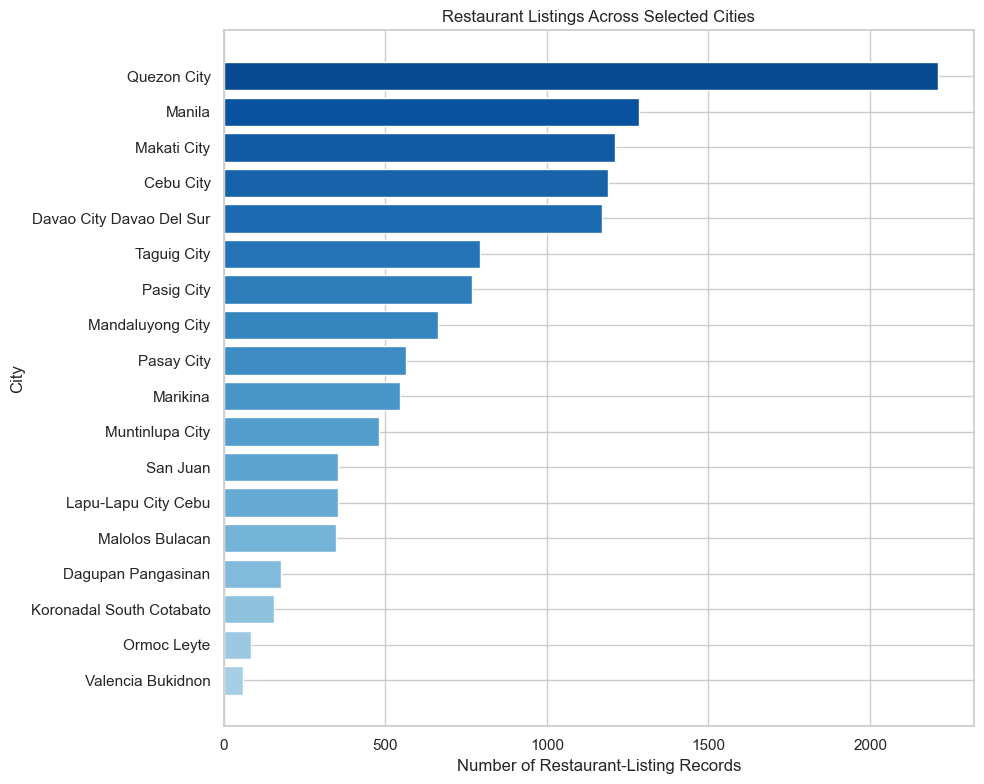

In [48]:
city_plot = city_distribution.sort_values(
    "ListingCount",
    ascending=True
)

colors = plt.cm.Blues(
    np.linspace(0.35, 0.90, len(city_plot))
)

plt.figure(figsize=(10, 8))
plt.barh(
    city_plot.index,
    city_plot["ListingCount"],
    color=colors
)

plt.title("Restaurant Listings Across Selected Cities")
plt.xlabel("Number of Restaurant-Listing Records")
plt.ylabel("City")
plt.xlim(left=0)
plt.tight_layout()

plt.savefig(
    "charts/01_city_listing_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Caption:** Quezon City accounts for the largest number of restaurant-listing records in the dataset, while Valencia, Bukidnon has the fewest.

**Caution:** This reflects Foodpanda dataset coverage, not the total restaurant population of each city.


## Chart 2 - Food-type diversity by city

This chart compares the number of unique food types represented in each city.


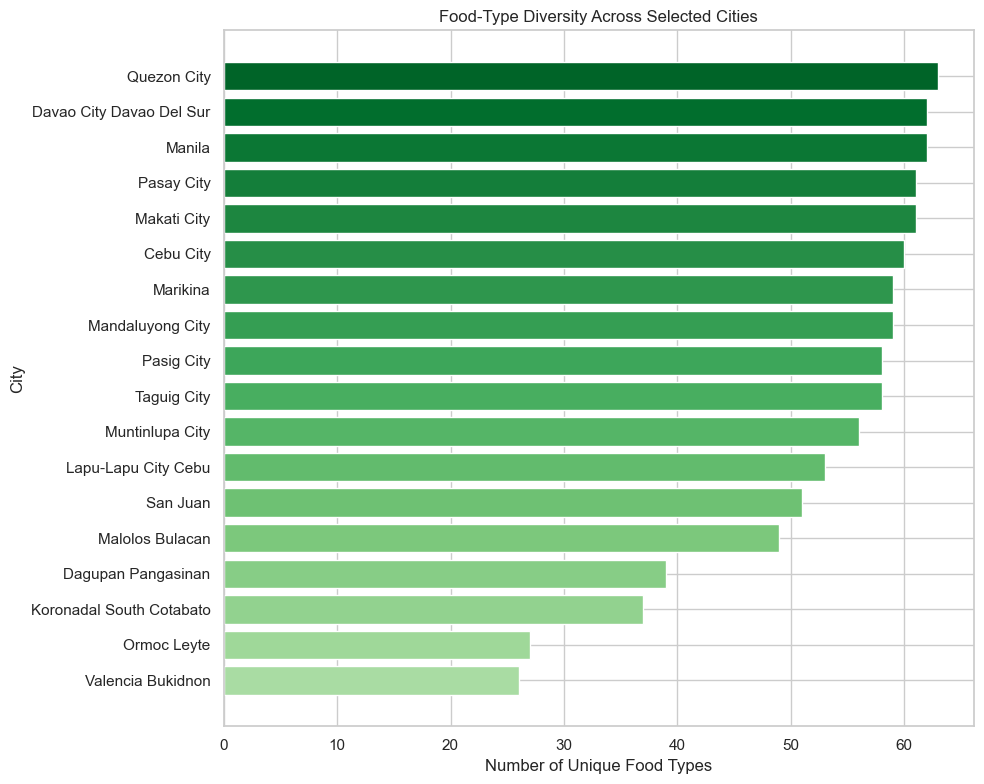

In [49]:
diversity_plot = city_diversity.sort_values(
    "UniqueFoodTypes",
    ascending=True
)

colors = plt.cm.Greens(
    np.linspace(0.35, 0.90, len(diversity_plot))
)

plt.figure(figsize=(10, 8))
plt.barh(
    diversity_plot.index,
    diversity_plot["UniqueFoodTypes"],
    color=colors
)

plt.title("Food-Type Diversity Across Selected Cities")
plt.xlabel("Number of Unique Food Types")
plt.ylabel("City")
plt.xlim(left=0)
plt.tight_layout()

plt.savefig(
    "charts/02_food_type_diversity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Caption:** The number of represented food types ranges from 26 in Valencia, Bukidnon to 63 in Quezon City, although cities with more captured listings have more opportunities to show greater variety.


## Chart 3 - Most represented food types

This chart identifies the named food types with the most listings across the selected cities.


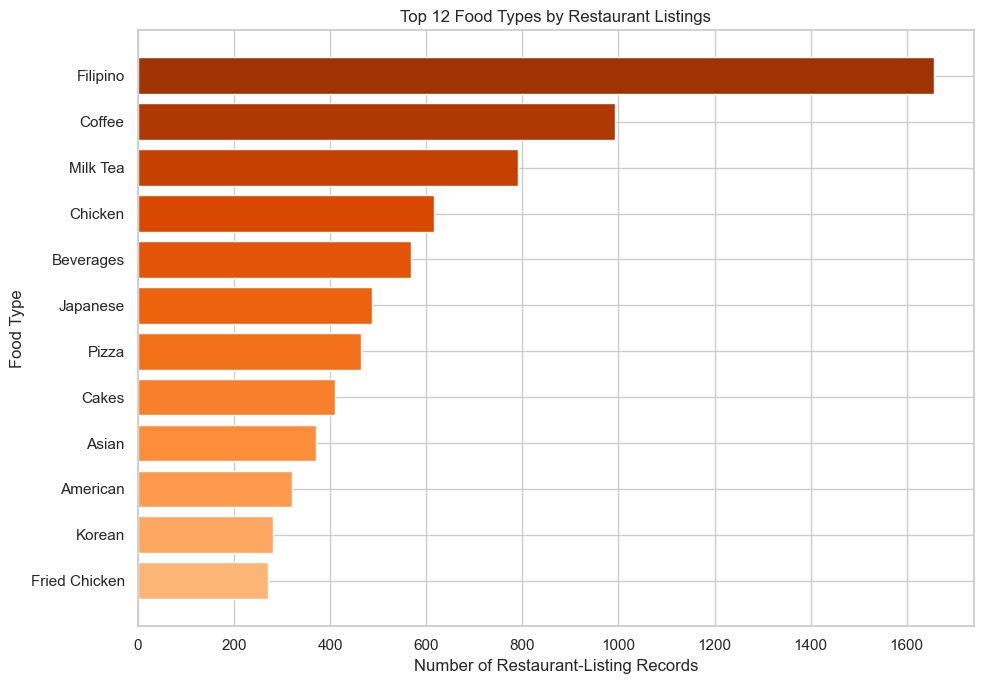

In [50]:
top_food_types = food_distribution.sort_values(
    "ListingCount",
    ascending=False
).head(12).sort_values(
    "ListingCount",
    ascending=True
)

colors = plt.cm.Oranges(
    np.linspace(0.35, 0.90, len(top_food_types))
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_food_types.index,
    top_food_types["ListingCount"],
    color=colors
)

plt.title("Top 12 Food Types by Restaurant Listings")
plt.xlabel("Number of Restaurant-Listing Records")
plt.ylabel("Food Type")
plt.xlim(left=0)
plt.tight_layout()

plt.savefig(
    "charts/03_top_food_types.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Caption:** Filipino food is the most represented category with 1,657 listings, followed by Coffee and Milk Tea.


## Chart 4 - Customer engagement and feedback by city

The left chart compares typical reviewer activity using the median. The right chart compares mean ratings using the full 0-to-5 scale.


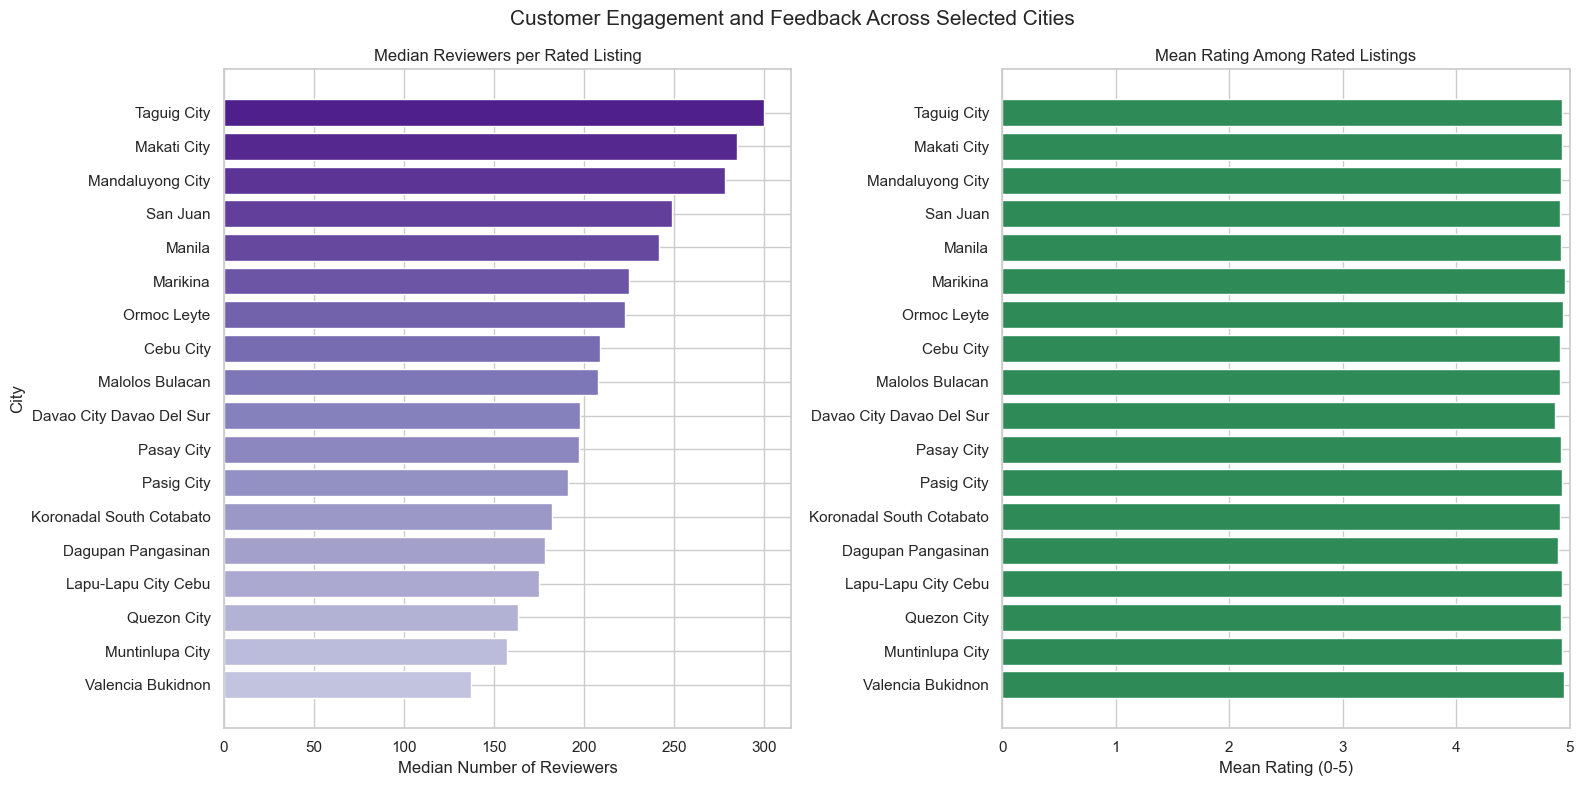

In [51]:
engagement_plot = city_engagement.sort_values(
    "MedianReviewers",
    ascending=True
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8)
)

axes[0].barh(
    engagement_plot.index,
    engagement_plot["MedianReviewers"],
    color=plt.cm.Purples(
        np.linspace(0.35, 0.90, len(engagement_plot))
    )
)
axes[0].set_title("Median Reviewers per Rated Listing")
axes[0].set_xlabel("Median Number of Reviewers")
axes[0].set_ylabel("City")
axes[0].set_xlim(left=0)

axes[1].barh(
    engagement_plot.index,
    engagement_plot["MeanRating"],
    color="seagreen"
)
axes[1].set_title("Mean Rating Among Rated Listings")
axes[1].set_xlabel("Mean Rating (0-5)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 5)

fig.suptitle(
    "Customer Engagement and Feedback Across Selected Cities",
    fontsize=15
)
plt.tight_layout()

plt.savefig(
    "charts/04_city_engagement_and_ratings.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Caption:** Median reviewer activity differs noticeably across cities, while mean ratings among rated listings remain closely clustered around 4.9.


## Chart 5 - Food-type diversity and reviewer activity

This chart compares food-type diversity and typical reviewer activity across the 18 selected cities. Each dot represents one city.

- Farther right = more represented food types
- Higher up = higher median reviewer count


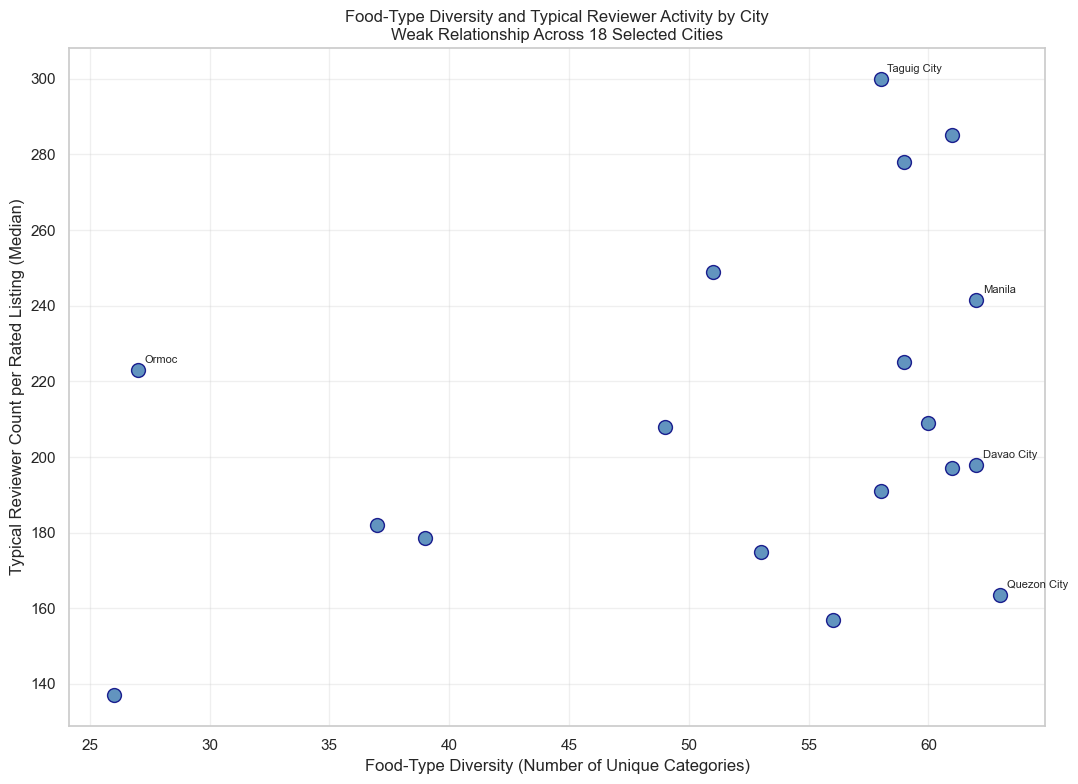

In [52]:

# Prepare city-level data for the chart
city_scatter = city_summary.reset_index()


# Create the scatter plot
plt.figure(figsize=(11, 8))

plt.scatter(
    city_scatter["UniqueFoodTypes"],
    city_scatter["MedianReviewers"],
    color="steelblue",
    edgecolor="navy",
    s=100,
    alpha=0.85
)


# Select cities that clearly explain the weak relationship
cities_to_label = [
    "Quezon City",
    "Taguig City",
    "Manila",
    "Davao City Davao Del Sur",
    "Ormoc Leyte"
]


# Add labels to the selected cities
for _, row in city_scatter.iterrows():

    if row["City"] in cities_to_label:

        city_label = row["City"]

        # Shorten long labels for the chart only
        if city_label == "Davao City Davao Del Sur":
            city_label = "Davao City"

        if city_label == "Ormoc Leyte":
            city_label = "Ormoc"

        plt.annotate(
            city_label,
            (
                row["UniqueFoodTypes"],
                row["MedianReviewers"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )


# Add clear titles and labels
plt.title(
    "Food-Type Diversity and Typical Reviewer Activity by City\n"
    "Weak Relationship Across 18 Selected Cities"
)

plt.xlabel("Food-Type Diversity (Number of Unique Categories)")
plt.ylabel("Typical Reviewer Count per Rated Listing (Median)")

plt.grid(alpha=0.3)
plt.tight_layout()


# Save and display the chart
plt.savefig(
    "charts/05_diversity_vs_reviewers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Caption:** Cities with more food types do not consistently show much higher reviewer activity. The relationship is weak, and the chart does not prove that one measure causes the other.


## Chart 6 - Food-type composition by city

The heatmap uses darker colors to show a larger percentage share of each leading food type within a city's known-food listings.


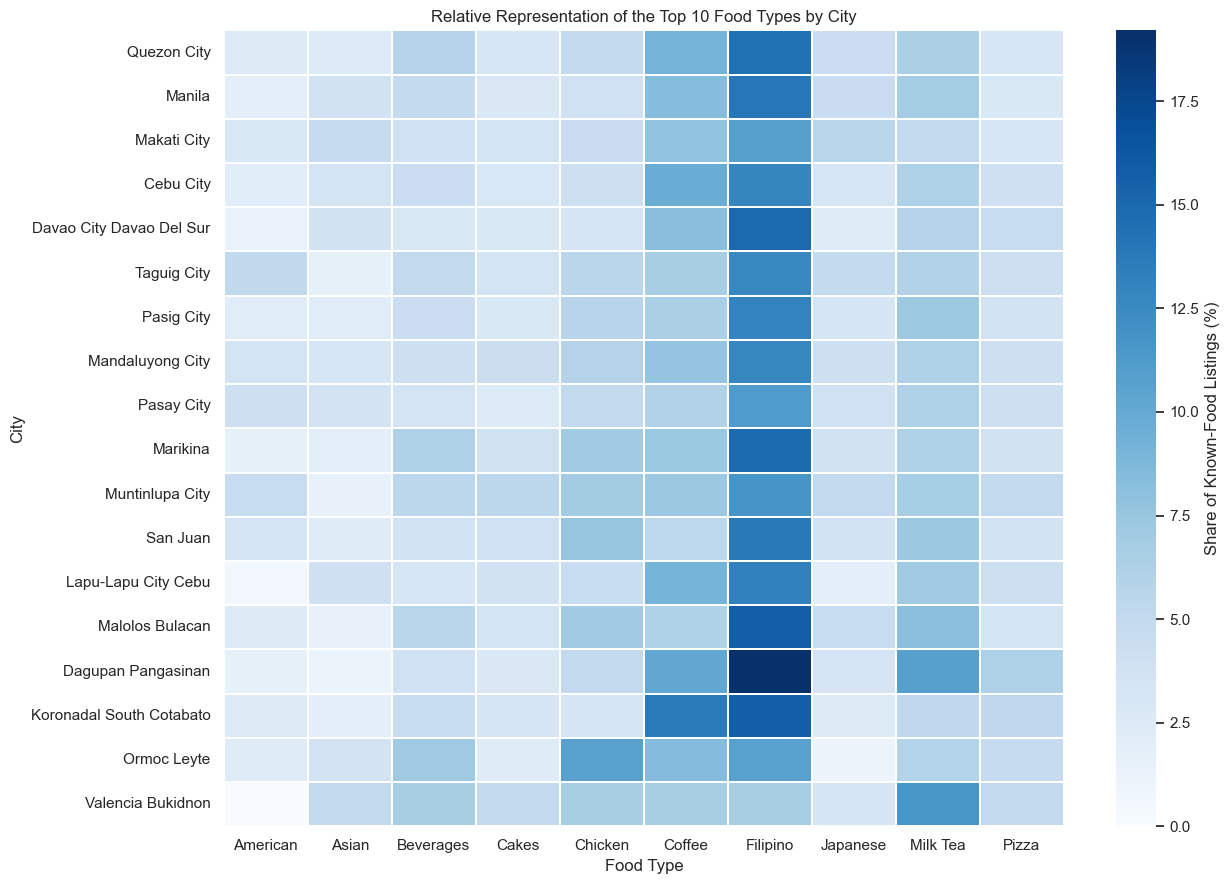

In [53]:
top_10_names = food_distribution.sort_values(
    "ListingCount",
    ascending=False
).head(10).index

heatmap_data = city_food[
    city_food["FoodType"].isin(top_10_names)
].pivot(
    index="City",
    columns="FoodType",
    values="ShareWithinCity"
).fillna(0)

city_order = city_distribution.sort_values(
    "ListingCount",
    ascending=False
).index

heatmap_data = heatmap_data.reindex(
    city_order
)

plt.figure(figsize=(13, 9))
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    linewidths=0.3,
    cbar_kws={
        "label": "Share of Known-Food Listings (%)"
    }
)

plt.title(
    "Relative Representation of the Top 10 Food Types by City"
)
plt.xlabel("Food Type")
plt.ylabel("City")
plt.tight_layout()

plt.savefig(
    "charts/06_food_type_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Caption:** Filipino food has the largest share of known-food listings in 16 of the 18 selected cities. Chicken leads in Ormoc, while Milk Tea leads in Valencia.

**Note:** Each percentage is based on all known-food listings within the city. Only the top 10 food types are displayed, so the visible percentages in each row do not total 100%.

## Final findings and limitations


In [54]:
top_city = city_distribution[
    "ListingCount"
].idxmax()

top_food_type = food_distribution[
    "ListingCount"
].idxmax()

most_diverse_city = city_diversity[
    "UniqueFoodTypes"
].idxmax()

print(
    "City with the most listings:",
    top_city,
    "-",
    city_distribution.loc[
        top_city, "ListingCount"
    ]
)

print(
    "Most represented food type:",
    top_food_type,
    "-",
    food_distribution.loc[
        top_food_type, "ListingCount"
    ]
)

print(
    "City with the most represented food types:",
    most_diverse_city,
    "-",
    city_diversity.loc[
        most_diverse_city,
        "UniqueFoodTypes"
    ]
)

print(
    "Listing-diversity correlation:",
    round(listing_diversity_rho, 3)
)
print(
    "Diversity-reviewer correlation:",
    round(diversity_rho, 3)
)

City with the most listings: Quezon City - 2211
Most represented food type: Filipino - 1657
City with the most represented food types: Quezon City - 63
Listing-diversity correlation: 0.938
Diversity-reviewer correlation: 0.274


### Short presentation summary

The number and mix of Foodpanda restaurant listings differ across the selected cities. Quezon City has the most captured listings and represented food types, while Filipino food is the most represented category overall. Cities with more captured listings generally show more food-type categories, although this likely reflects unequal dataset coverage. Reviewer activity varies across cities, but ratings among reviewed listings remain close to five. Food-type diversity and typical reviewer activity show only a weak, non-significant city-level relationship.

### Limitations

1. The data covers Foodpanda listings, not all operating restaurants in the Philippines.
2. Cities have different numbers of captured listings, so comparisons may reflect unequal coverage.
3. The original source, collection method, and exact 2025 coverage still need to be confirmed.
4. Missing food types and repeated store IDs may reflect platform or collection limitations.
5. The relationships are exploratory and do not prove causation.
